In [2]:
import pandas as pd
import zipfile
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



In [3]:
# Importar datos de empleo

file_path = r"C:\Users\santi\OneDrive\Documentos\VSC\TFG\estat_lfsi_emp_a.tsv.gz"

df_employment = pd.read_csv(file_path, sep="\t", compression="gzip")

print(df_employment.head())

  freq,indic_em,sex,age,unit,geo\TIME_PERIOD 2003  2004  2005  2006  2007   \
0                   A,ACT,F,Y15-24,PC_POP,AT    :     :     :     :     :    
1                   A,ACT,F,Y15-24,PC_POP,BA    :     :     :     :     :    
2                   A,ACT,F,Y15-24,PC_POP,BE    :     :     :     :     :    
3                   A,ACT,F,Y15-24,PC_POP,BG    :     :     :     :     :    
4                   A,ACT,F,Y15-24,PC_POP,CH    :     :     :     :     :    

  2008   2009    2010    2011   ...  2015   2016    2017   2018    2019   \
0    :   56.5    54.2    55.1   ...  54.4   54.9    53.9   54.0    52.7    
1    :      :       :       :   ...     :      :       :      :       :    
2    :   30.0    29.8    29.8   ...  27.3   26.2   25.5 b  27.8    29.5    
3    :   22.1   23.9 b  22.4 b  ...  19.1   17.5    19.4   17.2   17.7 b   
4    :      :   67.4 b   67.9   ...  68.3   69.0    67.8   67.6    66.3    

   2020   2021   2022   2023   2024   
0  52.7   51.5   53.2   55.7   53.7

In [4]:
# Importar datos de deuda pública

debt_file = r"C:\Users\santi\OneDrive\Documentos\VSC\TFG\estat_gov_10dd_edpt1.tsv.gz"

df_debt = pd.read_csv(debt_file, sep="\t", compression="gzip")

print(df_debt.head())

  freq,unit,sector,na_item,geo\TIME_PERIOD      1995       1996       1997   \
0                     A,MIO_EUR,S1,B1GQ,AT  183629.2   185944.9   186913.0    
1                     A,MIO_EUR,S1,B1GQ,BE  220251.5   219965.3   223032.7    
2                     A,MIO_EUR,S1,B1GQ,BG   14512.8     9829.8    10064.7    
3                     A,MIO_EUR,S1,B1GQ,CY    7596.0     7890.1     8414.3    
4                     A,MIO_EUR,S1,B1GQ,CZ   46333.6    53416.0    55174.6    

       1998       1999       2000       2001       2002       2003   ...  \
0  193947.1   203064.9   212406.8   219373.3   225087.9   230541.9   ...   
1  231015.7   242307.6   256376.4   264334.9   273255.9   281200.2   ...   
2   13437.6    12804.4    14440.0    15905.3    17478.3    18798.3   ...   
3    9152.6     9839.7    10804.6    11602.9    12083.0    12871.3   ...   
4   60164.9    61470.4    67409.2    76070.6    87795.9    88965.6   ...   

       2015       2016       2017       2018       2019       2020  

In [5]:
# Importar datos del PIB

gdp_file = r"C:\Users\santi\OneDrive\Documentos\VSC\TFG\estat_nama_10_gdp.tsv.gz"

df_gdp = pd.read_csv(gdp_file, sep="\t", compression="gzip")


print(df_gdp.head())

  freq,unit,na_item,geo\TIME_PERIOD 1975  1976  1977  1978  1979  1980  1981   \
0               A,CLV05_MEUR,B1G,AL    :     :     :     :     :     :     :    
1               A,CLV05_MEUR,B1G,AT    :     :     :     :     :     :     :    
2               A,CLV05_MEUR,B1G,BA    :     :     :     :     :     :     :    
3               A,CLV05_MEUR,B1G,BE    :     :     :     :     :     :     :    
4               A,CLV05_MEUR,B1G,BG    :     :     :     :     :     :     :    

  1982  1983   ...      2015       2016       2017       2018       2019   \
0    :     :   ...    7994.8     8305.9     8592.7     8914.3     9149.4    
1    :     :   ...  252957.6   258221.3   264412.6   271627.6   276482.8    
2    :     :   ...   9351.3 b    9650.5     9970.4    10347.6    10642.3    
3    :     :   ...  317686.5   320447.4   325019.4   331266.1   339917.3    
4    :     :   ...   26119.5    26792.6    27671.7    28590.9    29573.4    

       2020       2021       2022        2023     

In [6]:
# Importar datos de inflación

inflation_file = r"C:\Users\santi\OneDrive\Documentos\VSC\TFG\estat_prc_hicp_aind.tsv.gz"

df_inflation = pd.read_csv(inflation_file, sep="\t", compression="gzip")

print(df_inflation.head())

  freq,unit,coicop,geo\TIME_PERIOD 1996  1997  1998  1999  2000  2001   2002   \
0       A,CID_EA,TOT_X_NRG_FOOD,AT    :     :     :     :     :     :   -0.4    
1       A,CID_EA,TOT_X_NRG_FOOD,BE    :     :     :     :     :     :   -0.3    
2       A,CID_EA,TOT_X_NRG_FOOD,BG    :     :     :     :     :     :    5.3    
3       A,CID_EA,TOT_X_NRG_FOOD,CY    :     :     :     :     :     :   -1.4    
4       A,CID_EA,TOT_X_NRG_FOOD,CZ    :     :     :     :     :     :    0.1    

   2003   2004   ...  2015   2016   2017   2018   2019   2020   2021  2022   \
0  -0.6   -0.3   ...   0.7    0.8    1.1    0.8    0.6    1.3    0.8   1.1    
1  -0.3   -0.6   ...   0.6    0.9    0.5    0.3    0.5    0.7   -0.2   0.0    
2   0.3    0.3   ...  -1.7   -1.8   -1.5    1.1    0.8    0.5   -0.1   3.7    
3   0.1   -2.0   ...  -1.5   -1.6   -0.6   -0.9   -0.2   -1.5   -0.1   1.0    
4  -1.2    0.1   ...  -0.3    0.4    0.9    0.7    1.1    2.4    2.1   8.1    

   2023   2024   
0   2.4    1.1   
1 

In [7]:
# Importar datos del coeficiente de Gini

file_path = r'C:\Users\santi\OneDrive\Documentos\VSC\TFG\estat_ilc_di12b.tsv.gz'

df_gini = pd.read_csv(file_path, sep='\t', compression='gzip')

print(df_gini.head())

  freq,indic_il,geo\TIME_PERIOD  2003   2004   2005   2006   2007    2008   \
0                 A,GINI_HND,AL     :      :      :      :      :       :    
1                 A,GINI_HND,AT  46.2   43.9   45.0   45.0   46.3   46.3 b   
2                 A,GINI_HND,BE  50.8   48.6   50.6   48.7   46.7    48.0    
3                 A,GINI_HND,BG     :      :      :   52.8   50.4    49.7    
4                 A,GINI_HND,CH     :      :      :      :   46.5    48.1    

   2009   2010   2011   ...  2015    2016   2017   2018    2019   2020   \
0     :      :      :   ...     :       :   47.5   45.3    44.1   42.7    
1  46.8   47.9   47.6   ...  47.6    47.3   47.5   46.3    47.6   46.7    
2  46.6   46.5   47.1   ...  48.0    48.7   48.5   46.9   46.2 b  46.1    
3  46.4   46.7   48.1   ...  51.6   52.8 b  55.2   54.8    54.5   53.4    
4  48.1   48.9   48.9   ...  50.3    51.8   52.2   52.4    54.1   54.5    

   2021    2022   2023   2024   
0  43.1       :      :      :   
1  47.5   47.4

In [8]:
# Importar datos de desempleo

file_path_unemployment = r'C:\Users\santi\OneDrive\Documentos\VSC\TFG\estat_une_rt_a.tsv.gz'

df_unemployment = pd.read_csv(file_path_unemployment, sep='\t', compression='gzip')

print(df_unemployment.head())

  freq,age,unit,sex,geo\TIME_PERIOD 2003  2004  2005  2006  2007  2008   \
0              A,Y15-24,PC_ACT,F,AT    :     :     :     :     :     :    
1              A,Y15-24,PC_ACT,F,BA    :     :     :     :     :     :    
2              A,Y15-24,PC_ACT,F,BE    :     :     :     :     :     :    
3              A,Y15-24,PC_ACT,F,BG    :     :     :     :     :     :    
4              A,Y15-24,PC_ACT,F,CH    :     :     :     :     :     :    

   2009    2010    2011   ...  2015   2016    2017   2018     2019    2020   \
0  10.5     9.8     9.5   ...  10.4   10.7     9.1    9.8      8.1    10.6    
1     :       :       :   ...     :      :       :      :        :       :    
2  22.6    22.4    18.9   ...  20.5   18.3   18.2 b  15.3     12.3    15.6    
3  17.8   24.4 b  28.1 b  ...  26.7   21.1    16.3   15.7   11.8 bu  17.7 u   
4     :    8.7 b    7.9   ...   8.4    8.4     8.0    7.5      7.2     8.0    

    2021    2022    2023    2024   
0   11.3     9.5    10.7    10.1   
1 

In [9]:
# Store all dataframes in a dictionary
dfs = {
    'df_gini': df_gini,
    'df_unemployment': df_unemployment,
    'df_gdp': df_gdp,
    'df_employment': df_employment,
    'df_debt': df_debt,
    'df_inflation': df_inflation
}

# Inspect columns and sample rows for each
for name, df in dfs.items():
    print(f"\n--- {name} ---")
    print("Columns:", df.columns.tolist())
    print(df.head())  # Change to head() for more rows

for name, df in dfs.items():
    print(f"\n--- {name}.info() ---")
    df.info()



--- df_gini ---
Columns: ['freq,indic_il,geo\\TIME_PERIOD', '2003 ', '2004 ', '2005 ', '2006 ', '2007 ', '2008 ', '2009 ', '2010 ', '2011 ', '2012 ', '2013 ', '2014 ', '2015 ', '2016 ', '2017 ', '2018 ', '2019 ', '2020 ', '2021 ', '2022 ', '2023 ', '2024 ']
  freq,indic_il,geo\TIME_PERIOD  2003   2004   2005   2006   2007    2008   \
0                 A,GINI_HND,AL     :      :      :      :      :       :    
1                 A,GINI_HND,AT  46.2   43.9   45.0   45.0   46.3   46.3 b   
2                 A,GINI_HND,BE  50.8   48.6   50.6   48.7   46.7    48.0    
3                 A,GINI_HND,BG     :      :      :   52.8   50.4    49.7    
4                 A,GINI_HND,CH     :      :      :      :   46.5    48.1    

   2009   2010   2011   ...  2015    2016   2017   2018    2019   2020   \
0     :      :      :   ...     :       :   47.5   45.3    44.1   42.7    
1  46.8   47.9   47.6   ...  47.6    47.3   47.5   46.3    47.6   46.7    
2  46.6   46.5   47.1   ...  48.0    48.7   48.

In [10]:
print("Unemployment:", df_unemployment.columns.tolist())
print("Employment:", df_employment.columns.tolist())
print("Debt:", df_debt.columns.tolist())
print("GDP:", df_gdp.columns.tolist())
print("Inflation:", df_inflation.columns.tolist())
print("Gini:", df_gini.columns.tolist())


Unemployment: ['freq,age,unit,sex,geo\\TIME_PERIOD', '2003 ', '2004 ', '2005 ', '2006 ', '2007 ', '2008 ', '2009 ', '2010 ', '2011 ', '2012 ', '2013 ', '2014 ', '2015 ', '2016 ', '2017 ', '2018 ', '2019 ', '2020 ', '2021 ', '2022 ', '2023 ', '2024 ']
Employment: ['freq,indic_em,sex,age,unit,geo\\TIME_PERIOD', '2003 ', '2004 ', '2005 ', '2006 ', '2007 ', '2008 ', '2009 ', '2010 ', '2011 ', '2012 ', '2013 ', '2014 ', '2015 ', '2016 ', '2017 ', '2018 ', '2019 ', '2020 ', '2021 ', '2022 ', '2023 ', '2024 ']
Debt: ['freq,unit,sector,na_item,geo\\TIME_PERIOD', '1995 ', '1996 ', '1997 ', '1998 ', '1999 ', '2000 ', '2001 ', '2002 ', '2003 ', '2004 ', '2005 ', '2006 ', '2007 ', '2008 ', '2009 ', '2010 ', '2011 ', '2012 ', '2013 ', '2014 ', '2015 ', '2016 ', '2017 ', '2018 ', '2019 ', '2020 ', '2021 ', '2022 ', '2023 ', '2024 ']
GDP: ['freq,unit,na_item,geo\\TIME_PERIOD', '1975 ', '1976 ', '1977 ', '1978 ', '1979 ', '1980 ', '1981 ', '1982 ', '1983 ', '1984 ', '1985 ', '1986 ', '1987 ', '1988 ',

In [11]:
# Definir los filtros para los años y países
years = [str(y) + " " for y in range(2003, 2025)]  # Ajusta si tus columnas de año tienen otro formato
selected_countries = ['ES', 'EL', 'IT', 'FR', 'DE', 'AT', 'PT', 'NL']

def reshape_and_split_auto(df):
    """
    Convierte un DataFrame ancho a largo y separa automáticamente la columna compuesta.
    Detecta la columna que contiene 'geo' o 'geo\\TIME_PERIOD' y la renombra a 'country'.
    Filtra por los países definidos en selected_countries si existe la columna de país.
    """
    # Detectar la columna compuesta (la primera columna suele ser la compuesta)
    id_col = df.columns[0]
    id_vars = [id_col]
    # Melt a formato largo
    df_long = df.melt(
        id_vars=id_vars,
        value_vars=[col for col in df.columns if col in years],
        var_name="year",
        value_name="value"
    )
    # Limpiar y transformar year
    df_long["year"] = df_long["year"].str.strip().astype(int)
    # Separar columnas combinadas
    new_cols = id_col.split(",")
    df_long[new_cols] = df_long[id_col].str.split(",", expand=True)
    df_long = df_long.drop(columns=id_col)
    # Buscar columna país y renombrar
    geo_col = [col for col in new_cols if "geo" in col or "geo\\TIME_PERIOD" in col]
    if geo_col:
        df_long = df_long.rename(columns={geo_col[0]: "country"})
    # Filtrar países si corresponde
    if "country" in df_long.columns:
        df_long = df_long[df_long["country"].isin(selected_countries)]
    return df_long

# Ejemplo de uso con tu diccionario:
dfs_long = {name: reshape_and_split_auto(df) for name, df in dfs.items()}

In [12]:
for name, df in dfs.items():
    print(f"\n--- {name} ---")
    try:
        df_long = reshape_and_split_auto(df)
        print(f"Filas: {len(df_long)}")
        print("Columnas:", df_long.columns.tolist())
        print(df_long.head())
    except Exception as e:
        print(f"Error procesando {name}: {e}")


--- df_gini ---
Filas: 176
Columnas: ['year', 'value', 'freq', 'indic_il', 'country']
    year  value freq  indic_il country
1   2003  46.2     A  GINI_HND      AT
7   2003     :     A  GINI_HND      DE
14  2003  49.0     A  GINI_HND      EL
15  2003     :     A  GINI_HND      ES
21  2003     :     A  GINI_HND      FR

--- df_unemployment ---
Filas: 11088
Columnas: ['year', 'value', 'freq', 'age', 'unit', 'sex', 'country']
    year  value freq     age    unit sex country
0   2003     :     A  Y15-24  PC_ACT   F      AT
7   2003     :     A  Y15-24  PC_ACT   F      DE
11  2003     :     A  Y15-24  PC_ACT   F      EL
12  2003     :     A  Y15-24  PC_ACT   F      ES
15  2003  22.7     A  Y15-24  PC_ACT   F      FR

--- df_gdp ---
Filas: 143748
Columnas: ['year', 'value', 'freq', 'unit', 'na_item', 'country']
    year       value freq        unit na_item country
1   2003   212983.4     A  CLV05_MEUR     B1G      AT
8   2003  2044693.9     A  CLV05_MEUR     B1G      DE
15  2003   162443.5 

In [13]:
df_employment_long = reshape_and_split_auto(df_employment)
df_unemployment_long = reshape_and_split_auto(df_unemployment)
df_debt_long = reshape_and_split_auto(df_debt)
df_gdp_long = reshape_and_split_auto(df_gdp)
df_inflation_long = reshape_and_split_auto(df_inflation)
df_gini_long = reshape_and_split_auto(df_gini)

In [14]:
print("age:", df_employment_long["age"].unique())
print("sex:", df_employment_long["sex"].unique())
print("unit:", df_employment_long["unit"].unique())
print("freq:", df_employment_long["freq"].unique())
print("indic_em:", df_employment_long["indic_em"].unique())

age: ['Y15-24' 'Y15-29' 'Y15-64' 'Y20-64' 'Y25-54' 'Y55-64']
sex: ['F' 'M' 'T']
unit: ['PC_POP' 'THS_PER']
freq: ['A']
indic_em: ['ACT' 'EMP_LFS']


In [15]:
print("age:", df_unemployment_long["age"].unique())
print("sex:", df_unemployment_long["sex"].unique())
print("unit:", df_unemployment_long["unit"].unique())
print("freq:", df_unemployment_long["freq"].unique())

age: ['Y15-24' 'Y15-29' 'Y15-74' 'Y20-64' 'Y25-54' 'Y25-74' 'Y55-74']
sex: ['F' 'M' 'T']
unit: ['PC_ACT' 'PC_POP' 'THS_PER']
freq: ['A']


In [16]:
print("freq:", df_debt_long["freq"].unique())
print("unit:", df_debt_long["unit"].unique())
print("sector:", df_debt_long["sector"].unique())
print("na_item:", df_debt_long["na_item"].unique())
print("country:", df_debt_long["country"].unique())

freq: ['A']
unit: ['MIO_EUR' 'MIO_NAC' 'PC_GDP']
sector: ['S1' 'S13' 'S1311' 'S1312' 'S1313' 'S1314']
na_item: ['B1GQ' 'B5GQ' 'AF_81L' 'B9' 'D41PAY' 'GD' 'GD_F2' 'GD_F3' 'GD_F31'
 'GD_F32' 'GD_F4' 'GD_F41' 'GD_F42' 'IGL_F4_EA19' 'IGL_F4_EA20'
 'IGL_F4_EU27_2020' 'P51G']
country: ['AT' 'DE' 'EL' 'ES' 'FR' 'IT' 'NL' 'PT']


In [17]:
print("freq:", df_gdp_long["freq"].unique())
print("unit:", df_gdp_long["unit"].unique())
print("na_item:", df_gdp_long["na_item"].unique())
print("country:", df_gdp_long["country"].unique())

freq: ['A']
unit: ['CLV05_MEUR' 'CLV05_MNAC' 'CLV10_MEUR' 'CLV10_MNAC' 'CLV15_MEUR'
 'CLV15_MNAC' 'CLV20_MEUR' 'CLV20_MNAC' 'CLV_I05' 'CLV_I10' 'CLV_I15'
 'CLV_I20' 'CLV_PCH_PRE' 'CON_PPCH_PRE' 'CP_MEUR' 'CP_MNAC'
 'CP_MPPS_EU27_2020' 'PC_EU27_2020_MEUR_CP' 'PC_EU27_2020_MPPS_CP'
 'PC_GDP' 'PD05_EUR' 'PD05_NAC' 'PD10_EUR' 'PD10_NAC' 'PD15_EUR'
 'PD15_NAC' 'PD20_EUR' 'PD20_NAC' 'PD_PCH_PRE_EUR' 'PD_PCH_PRE_NAC'
 'PYP_MEUR' 'PYP_MNAC']
na_item: ['B1G' 'B1GQ' 'D21' 'D21X31' 'D31' 'P3' 'P31_S13' 'P31_S14' 'P31_S14_S15'
 'P31_S15' 'P32_S13' 'P3_P5' 'P3_P6' 'P3_S13' 'P41' 'P51G' 'P5G' 'P6'
 'P61' 'P62' 'P7' 'P71' 'P72' 'P52_P53' 'B11' 'B111' 'B112' 'B2A3G' 'D1'
 'D11' 'D12' 'D2' 'D2X3' 'D3' 'P52' 'P53' 'YA0' 'YA1' 'YA2']
country: ['AT' 'DE' 'EL' 'ES' 'FR' 'IT' 'NL' 'PT']


In [18]:
print("freq:", df_inflation_long["freq"].unique())
print("unit:", df_inflation_long["unit"].unique())
print("coicop:", df_inflation_long["coicop"].unique())
print("country:", df_inflation_long["country"].unique())

freq: ['A']
unit: ['CID_EA' 'INX_A_AVG' 'RCH_A_AVG']
coicop: ['TOT_X_NRG_FOOD' 'AP' 'APF' 'APM' 'AP_NNRG' 'AP_NRG' 'CP00' 'CP01'
 'CP011' 'CP0111' 'CP01111' 'CP01112' 'CP01113' 'CP01114' 'CP01115'
 'CP01116' 'CP01117' 'CP01118' 'CP0112' 'CP01121' 'CP01122' 'CP01123'
 'CP01124' 'CP01125' 'CP01126' 'CP01127' 'CP01128' 'CP0113' 'CP01131'
 'CP01132' 'CP01133' 'CP01134' 'CP01135' 'CP01136' 'CP0114' 'CP01141'
 'CP01142' 'CP01143' 'CP01144' 'CP01145' 'CP01146' 'CP01147' 'CP0115'
 'CP01151' 'CP01152' 'CP01153' 'CP01154' 'CP01155' 'CP0116' 'CP01161'
 'CP01162' 'CP01163' 'CP01164' 'CP0117' 'CP01171' 'CP01172' 'CP01173'
 'CP01174' 'CP01175' 'CP01176' 'CP0118' 'CP01181' 'CP01182' 'CP01183'
 'CP01184' 'CP01185' 'CP01186' 'CP0119' 'CP01191' 'CP01192' 'CP01193'
 'CP01194' 'CP01199' 'CP012' 'CP0121' 'CP01211' 'CP01212' 'CP01213'
 'CP0122' 'CP01221' 'CP01222' 'CP01223' 'CP02' 'CP021' 'CP0211' 'CP02111'
 'CP02112' 'CP0212' 'CP02121' 'CP02122' 'CP02123' 'CP02124' 'CP0213'
 'CP02131' 'CP02132' 'CP02133' '

In [19]:
print("freq:", df_gini_long["freq"].unique())
print("indic_il:", df_gini_long["indic_il"].unique())
print("country:", df_gini_long["country"].unique())

freq: ['A']
indic_il: ['GINI_HND']
country: ['AT' 'DE' 'EL' 'ES' 'FR' 'IT' 'NL' 'PT']


In [20]:
# Aplicar filtros

# Empleo total (tasa de empleo 15-64 años, ambos sexos, anual, fuente LFS)
totals_emp = df_employment_long[
    (df_employment_long["sex"] == "T") &
    (df_employment_long["age"] == "Y15-64") &
    (df_employment_long["unit"] == "PC_POP") &
    (df_employment_long["freq"] == "A") &
    (df_employment_long["indic_em"] == "EMP_LFS")
].copy()

# Desempleo total (tasa de paro 15-74 años, ambos sexos, anual, sobre población)
totals_unemp = df_unemployment_long[
    (df_unemployment_long["sex"] == "T") &
    (df_unemployment_long["age"] == "Y15-74") &
    (df_unemployment_long["unit"] == "PC_POP") &
    (df_unemployment_long["freq"] == "A")
].copy()

# Deuda pública como % del PIB (sector S13 = Administraciones Públicas, GD = Gross Debt)
totals_debt_pct = df_debt_long[
    (df_debt_long["freq"] == "A") &
    (df_debt_long["unit"] == "PC_GDP") &
    (df_debt_long["sector"] == "S13") &
    (df_debt_long["na_item"] == "GD")
].copy()

# PIB nominal (millones de euros, precios corrientes)
gdp_nominal = df_gdp_long[
    (df_gdp_long["unit"] == "CP_MEUR") &
    (df_gdp_long["na_item"] == "B1G")
].copy()

# PIB real (millones de euros, precios constantes 2010)
gdp_real = df_gdp_long[
    (df_gdp_long["unit"] == "CLV10_MEUR") &
    (df_gdp_long["na_item"] == "B1G")
].copy()

# Inflación armonizada (anual, índice armonizado, excluyendo energía y alimentos no elaborados)
totals_inflation = df_inflation_long[
    (df_inflation_long["freq"] == "A") &
    (df_inflation_long["unit"] == "CID_EA") &
    (df_inflation_long["coicop"] == "TOT_X_NRG_FOOD")
].copy()

# Gini después de transferencias sociales (el estándar internacional)
totals_gini = df_gini_long[
    (df_gini_long["indic_il"] == "GINI_HND")
].copy()

In [21]:
# Verifica las dimensiones y columnas de los DataFrames de totales antes del merge

print("totals_emp:", totals_emp.shape, totals_emp.columns.tolist())
print(totals_emp.head())

print("totals_unemp:", totals_unemp.shape, totals_unemp.columns.tolist())
print(totals_unemp.head())

print("totals_debt_pct:", totals_debt_pct.shape, totals_debt_pct.columns.tolist())
print(totals_debt_pct.head())

print("gdp_nominal:", gdp_nominal.shape, gdp_nominal.columns.tolist())
print(gdp_nominal.head())

print("gdp_real:", gdp_real.shape, gdp_real.columns.tolist())
print(gdp_real.head())

print("totals_inflation:", totals_inflation.shape, totals_inflation.columns.tolist())
print(totals_inflation.head())

print("totals_gini:", totals_gini.shape, totals_gini.columns.tolist())
print(totals_gini.head())

totals_emp: (176, 8) ['year', 'value', 'freq', 'indic_em', 'sex', 'age', 'unit', 'country']
      year  value freq indic_em sex     age    unit country
2368  2003     :     A  EMP_LFS   T  Y15-64  PC_POP      AT
2375  2003     :     A  EMP_LFS   T  Y15-64  PC_POP      DE
2379  2003     :     A  EMP_LFS   T  Y15-64  PC_POP      EL
2380  2003     :     A  EMP_LFS   T  Y15-64  PC_POP      ES
2383  2003  64.4     A  EMP_LFS   T  Y15-64  PC_POP      FR
totals_unemp: (176, 7) ['year', 'value', 'freq', 'age', 'unit', 'sex', 'country']
     year value freq     age    unit sex country
851  2003    :     A  Y15-74  PC_POP   T      AT
858  2003    :     A  Y15-74  PC_POP   T      DE
862  2003    :     A  Y15-74  PC_POP   T      EL
863  2003    :     A  Y15-74  PC_POP   T      ES
866  2003  5.3     A  Y15-74  PC_POP   T      FR
totals_debt_pct: (176, 7) ['year', 'value', 'freq', 'unit', 'sector', 'na_item', 'country']
      year   value freq    unit sector na_item country
1552  2003   66.4     A  

In [22]:
# Renombra la columna 'value' de cada DataFrame antes de mergear para evitar conflictos
totals_emp = totals_emp.rename(columns={"value": "employment_rate"})
totals_unemp = totals_unemp.rename(columns={"value": "unemployment_rate"})
totals_debt_pct = totals_debt_pct.rename(columns={"value": "debt_pct_gdp"})
gdp_nominal = gdp_nominal.rename(columns={"value": "gdp_nominal"})
gdp_real = gdp_real.rename(columns={"value": "gdp_real"})
totals_inflation = totals_inflation.rename(columns={"value": "inflation"})
totals_gini = totals_gini.rename(columns={"value": "gini"})

# Selecciona solo las columnas clave para el merge
def select_cols(df, value_col):
    return df[["country", "year", value_col]]

df_merged = totals_emp[["country", "year", "employment_rate"]]
df_merged = df_merged.merge(select_cols(totals_unemp, "unemployment_rate"), on=["country", "year"], how="outer")
df_merged = df_merged.merge(select_cols(totals_debt_pct, "debt_pct_gdp"), on=["country", "year"], how="outer")
df_merged = df_merged.merge(select_cols(gdp_nominal, "gdp_nominal"), on=["country", "year"], how="outer")
df_merged = df_merged.merge(select_cols(gdp_real, "gdp_real"), on=["country", "year"], how="outer")
df_merged = df_merged.merge(select_cols(totals_inflation, "inflation"), on=["country", "year"], how="outer")
df_merged = df_merged.merge(select_cols(totals_gini, "gini"), on=["country", "year"], how="outer")

print(df_merged.shape)
print(df_merged.head())

(176, 9)
  country  year employment_rate unemployment_rate debt_pct_gdp gdp_nominal  \
0      AT  2003              :                 :         66.4    205864.5    
1      AT  2004              :                 :         65.9    214252.0    
2      AT  2005              :                 :         69.4    224194.7    
3      AT  2006              :                 :         68.2    237133.7    
4      AT  2007              :                 :         65.8    251596.6    

    gdp_real inflation   gini  
0  232349.2      -0.6   46.2   
1  238705.2      -0.3   43.9   
2  244579.9      -0.1   45.0   
3  253261.7      -0.2   45.0   
4  263069.7      -0.2   46.3   


In [23]:
zip_path = r"C:\Users\santi\OneDrive\Documentos\VSC\TFG\parlgov-development_csv-utf-8.zip"

# Lista los archivos dentro del ZIP para confirmar los nombres
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    print(zip_ref.namelist())

# Carga view_election.csv
with zipfile.ZipFile(zip_path) as z:
    with z.open("view_election.csv") as f:
        df_election = pd.read_csv(f)
print("view_election.csv loaded:", df_election.shape)
print(df_election.head())

# Carga view_cabinet.csv
with zipfile.ZipFile(zip_path) as z:
    with z.open("view_cabinet.csv") as f:
        df_cabinet = pd.read_csv(f)
print("view_cabinet.csv loaded:", df_cabinet.shape)
print(df_cabinet.head())

['info_data_source.csv', 'external_party_castles_mair.csv', 'external_party_chess.csv', 'external_party_huber_inglehart.csv', 'info_table.csv', 'external_party_euprofiler.csv', 'party_family.csv', 'info_id.csv', 'sqlite_stat1.csv', 'external_party_benoit_laver.csv', 'external_country_iso.csv', 'viewcalc_party_position.csv', 'viewcalc_election_parameter.csv', 'viewcalc_parliament_composition.csv', 'viewcalc_country_year_share.csv', 'country.csv', 'election_result.csv', 'party.csv', 'external_commissioner_doering.csv', 'cabinet_party.csv', 'external_party_cmp.csv', 'info_variable.csv', 'cabinet.csv', 'election.csv', 'external_party_ray.csv', 'external_party_ees.csv', 'party_change.csv', 'party_name_change.csv', 'politician_president.csv', 'view_party.csv', 'view_election.csv', 'view_cabinet.csv', 'view_variable.csv']
view_election.csv loaded: (8997, 16)
  country_name_short country_name election_type election_date  vote_share  \
0                AUS    Australia    parliament    1901-03-

In [24]:
# Estandarizar los nombres de las columnas para los DataFrames de elecciones y gabinetes

# Para elecciones
df_election['year'] = pd.to_datetime(df_election['election_date'], errors='coerce').dt.year.astype(int)
df_election['country'] = df_election['country_name_short'].astype(str)

# Para gabinetes
df_cabinet['year'] = pd.to_datetime(df_cabinet['start_date'], errors='coerce').dt.year.astype(int)
df_cabinet['country'] = df_cabinet['country_name_short'].astype(str)

In [25]:
# Ver columnas de view_election.csv
print("view_election.csv columns:", df_election.columns.tolist())

# Ver columnas de view_cabinet.csv
print("view_cabinet.csv columns:", df_cabinet.columns.tolist())

view_election.csv columns: ['country_name_short', 'country_name', 'election_type', 'election_date', 'vote_share', 'seats', 'seats_total', 'party_name_short', 'party_name', 'party_name_english', 'left_right', 'country_id', 'election_id', 'previous_parliament_election_id', 'previous_cabinet_id', 'party_id', 'year', 'country']
view_cabinet.csv columns: ['country_name_short', 'country_name', 'election_date', 'start_date', 'cabinet_name', 'caretaker', 'cabinet_party', 'prime_minister', 'seats', 'election_seats_total', 'party_name_short', 'party_name', 'party_name_english', 'left_right', 'country_id', 'election_id', 'cabinet_id', 'previous_cabinet_id', 'party_id', 'year', 'country']


In [26]:
# Revisa los valores únicos de país y año en ambos DataFrames

print("Países en df_election:", df_election['country_name_short'].unique())
print("Años en df_election:", sorted(df_election['election_date'].unique()))
print("Países en df_cabinet:", df_cabinet['country_name_short'].unique())
print("Años en df_cabinet:", sorted(df_cabinet['start_date'].unique()))

Países en df_election: ['AUS' 'AUT' 'BEL' 'BGR' 'CAN' 'CHE' 'CYP' 'CZE' 'DEU' 'DNK' 'ESP' 'EST'
 'FIN' 'FRA' 'GBR' 'GRC' 'HRV' 'HUN' 'IRL' 'ISL' 'ISR' 'ITA' 'JPN' 'LTU'
 'LUX' 'LVA' 'MLT' 'NLD' 'NOR' 'NZL' 'POL' 'PRT' 'ROU' 'SVK' 'SVN' 'SWE'
 'TUR']
Años en df_election: ['1900-05-27', '1900-07-01', '1900-11-07', '1901-03-30', '1901-04-03', '1902-05-11', '1902-05-25', '1902-10-26', '1902-11-25', '1903-06-16', '1903-09-16', '1903-12-16', '1904-05-29', '1904-11-03', '1905-10-29', '1905-12-06', '1906-05-20', '1906-05-27', '1906-05-29', '1906-08-27', '1906-12-02', '1908-05-24', '1908-10-25', '1908-10-26', '1908-12-01', '1909-05-25', '1909-10-25', '1910-04-13', '1910-05-08', '1910-05-20', '1910-05-22', '1911-09-21', '1911-09-24', '1911-10-29', '1911-12-19', '1912-06-02', '1912-10-21', '1913-05-20', '1913-05-31', '1914-04-07', '1914-05-10', '1914-05-24', '1914-09-05', '1914-09-13', '1914-10-25', '1914-12-11', '1915-05-07', '1915-10-21', '1917-05-05', '1917-09-16', '1917-10-02', '1917-10-28', 

In [27]:
# Define los países de interés (códigos de 3 letras)
selected_countries = ['ESP', 'GRC', 'ITA', 'FRA', 'DEU', 'AUT', 'PRT', 'NLD']

# Filtra solo elecciones generales (parliament) y países seleccionados
mask = (
    (df_election['country_name_short'].isin(selected_countries)) &
    (df_election['election_type'] == 'parliament') &
    (pd.to_datetime(df_election['election_date'], errors='coerce').dt.year < 2008)
)
df_pre2008 = df_election[mask].copy()

# Extrae el año de la elección
df_pre2008['election_year'] = pd.to_datetime(df_pre2008['election_date'], errors='coerce').dt.year

# Para cada país, muestra el último año de elección antes de 2008
for country, group in df_pre2008.groupby('country_name_short'):
    years = sorted(group['election_year'].unique())
    if years:
        print(f"{country}: último año antes de 2008 -> {years[-1]}")
    else:
        print(f"{country}: sin elecciones antes de 2008")

AUT: último año antes de 2008 -> 2006
DEU: último año antes de 2008 -> 2005
ESP: último año antes de 2008 -> 2004
FRA: último año antes de 2008 -> 2007
GRC: último año antes de 2008 -> 2007
ITA: último año antes de 2008 -> 2006
NLD: último año antes de 2008 -> 2006
PRT: último año antes de 2008 -> 2005


In [28]:
# Filtrar por países y años específicos

selected_countries = ['ESP', 'GRC', 'ITA', 'FRA', 'DEU', 'AUT', 'PRT', 'NLD']
years = list(range(2000, 2024))  # 2000-2023 inclusive

# Asegúrate de tener la columna 'election_year'
df_election['election_year'] = pd.to_datetime(df_election['election_date'], errors='coerce').dt.year

# Obtén el último año de elección antes de 2008 para cada país
mask_pre2008 = (
    (df_election['country_name_short'].isin(selected_countries)) &
    (df_election['election_type'] == 'parliament') &
    (df_election['election_year'] < 2008)
)
df_pre2008 = df_election[mask_pre2008].copy()

last_pre2008 = (
    df_pre2008.groupby('country_name_short')['election_year']
    .max()
    .reset_index()
)

# Filtra las elecciones de 2000 a 2023
df_election_filtered = df_election[
    (df_election['country_name_short'].isin(selected_countries)) &
    (df_election['election_year'].isin(years))
]

# Incluye las últimas elecciones previas a 2008
df_prev_elections = pd.merge(
    df_election,
    last_pre2008,
    left_on=['country_name_short', 'election_year'],
    right_on=['country_name_short', 'election_year'],
    how='inner'
)

# Une las elecciones previas con las de 2000-2023
df_election_final = pd.concat([df_election_filtered, df_prev_elections], ignore_index=True)

# Elimina duplicados por si acaso
df_election_final = df_election_final.drop_duplicates()

# Filtra gabinetes solo para los años de elecciones seleccionados
election_years_for_cabinets = df_election_final['election_year'].unique().tolist()
df_cabinet_final = df_cabinet[
    (df_cabinet['country_name_short'].isin(selected_countries)) &
    (df_cabinet['year'].isin(election_years_for_cabinets))
]

print("df_election_final:", df_election_final.shape)
print("df_cabinet_final:", df_cabinet_final.shape)

df_election_final: (924, 19)
df_cabinet_final: (881, 21)


In [29]:
# Calcula el índice de Pedersen de volatilidad electoral por país y año

# 1. Ordena y selecciona solo las columnas necesarias
df_election_final = df_election_final.sort_values(['country_name_short', 'election_year', 'party_id'])

# 2. Crea una tabla pivote: filas=país, año, columnas=partido, valores=vote_share
pivot = df_election_final.pivot_table(
    index=['country_name_short', 'election_year'],
    columns='party_id',
    values='vote_share',
    fill_value=0
).sort_index()

# 3. Calcula la diferencia absoluta entre elecciones consecutivas para cada país
pedersen_results = []
for country, group in pivot.groupby(level=0):
    group_sorted = group.sort_index()
    prev = None
    for year, row in group_sorted.iterrows():
        if prev is not None:
            diff = (row - prev).abs().sum() / 2
            pedersen_results.append({
                'country_name_short': country,
                'election_year': year,
                'pedersen_index': diff
            })
        prev = row

df_pedersen = pd.DataFrame(pedersen_results)

In [30]:
# Estandarizar los tipos de variables de años y solucionar problemas si se encuentran tuplas

# Si election_year contiene tuplas, extrae el año
if isinstance(df_pedersen['election_year'].iloc[0], tuple):
    df_pedersen['election_year'] = df_pedersen['election_year'].apply(lambda x: x[1] if isinstance(x, tuple) else x)

# Si year contiene tuplas, extrae el año
if 'year' in df_pedersen.columns and isinstance(df_pedersen['year'].iloc[0], tuple):
    df_pedersen['year'] = df_pedersen['year'].apply(lambda x: x[1] if isinstance(x, tuple) else x)
else:
    df_pedersen['year'] = df_pedersen['election_year']

# Mapas de códigos a nombres completos
country_map = {
    'AUT': 'AT',
    'ESP': 'ES',
    'GRC': 'EL',
    'ITA': 'IT',
    'FRA': 'FR',
    'DEU': 'DE',
    'PRT': 'PT',
    'NLD': 'NL'
}
country_fullname = {
    'AT': 'Austria',
    'ES': 'España',
    'EL': 'Grecia',
    'IT': 'Italia',
    'FR': 'Francia',
    'DE': 'Alemania',
    'PT': 'Portugal',
    'NL': 'Países Bajos'
}

# Aplica el mapeo de 3 letras a 2 letras
df_pedersen['country_code'] = df_pedersen['country_name_short'].map(country_map)
# Aplica el mapeo de 2 letras a nombre completo
df_pedersen['country'] = df_pedersen['country_code'].map(country_fullname)

# Haz lo mismo para df_merged si es necesario
df_merged['country'] = df_merged['country'].map(country_fullname)

# Convertir a tipos correctos
df_pedersen['year'] = df_pedersen['year'].astype(int)
df_merged['year'] = df_merged['year'].astype(int)

# Une los DataFrames por país y año (ahora usando nombres completos)
df_analysis = pd.merge(df_pedersen, df_merged, on=['country', 'year'], how='left')

print(df_analysis.head())

  country_name_short  election_year  pedersen_index  year country_code  \
0                AUT           2004          17.820  2004           AT   
1                AUT           2006          12.775  2006           AT   
2                AUT           2008          17.910  2008           AT   
3                AUT           2009          21.300  2009           AT   
4                AUT           2013          24.950  2013           AT   

   country employment_rate unemployment_rate debt_pct_gdp gdp_nominal  \
0  Austria              :                 :         65.9    214252.0    
1  Austria              :                 :         68.2    237133.7    
2  Austria              :                 :         69.5    260417.8    
3  Austria           70.3               3.8         80.8    254814.8    
4  Austria           71.4               3.8         82.4    285327.0    

    gdp_real inflation    gini  
0  238705.2      -0.3    43.9   
1  253261.7      -0.2    45.0   
2  267521.4      

In [31]:
# Cambia el nombre de la columna 'country_name_short' por 'country_short'
df_analysis = df_analysis.rename(columns={'country_name_short': 'country_short'})

# Elimina la columna 'country_code'
if 'country_code' in df_analysis.columns:
    df_analysis = df_analysis.drop(columns=['country_code'])

# Mueve la columna 'country' al inicio
cols = df_analysis.columns.tolist()
if 'country' in cols:
    cols.insert(0, cols.pop(cols.index('country')))
    df_analysis = df_analysis[cols]

# Elimina la columna 'year' de df_analysis antes de continuar
df_analysis = df_analysis.drop(columns=['year'])

print(df_analysis.head())

   country country_short  election_year  pedersen_index employment_rate  \
0  Austria           AUT           2004          17.820              :    
1  Austria           AUT           2006          12.775              :    
2  Austria           AUT           2008          17.910              :    
3  Austria           AUT           2009          21.300           70.3    
4  Austria           AUT           2013          24.950           71.4    

  unemployment_rate debt_pct_gdp gdp_nominal   gdp_real inflation    gini  
0                :         65.9    214252.0   238705.2      -0.3    43.9   
1                :         68.2    237133.7   253261.7      -0.2    45.0   
2                :         69.5    260417.8   267521.4      -0.1   46.3 b  
3              3.8         80.8    254814.8   256808.8       0.3    46.8   
4              3.8         82.4    285327.0   271001.3       1.1    47.0   


In [32]:
# Ejemplo de regresión lineal con statsmodels

# Selecciona las variables independientes y dependiente forzando errores a NaN
for col in ['employment_rate', 'unemployment_rate', 'debt_pct_gdp', 'gdp_nominal', 'gdp_real', 'inflation', 'gini']:
    df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')

X = df_analysis[['employment_rate', 'unemployment_rate', 'debt_pct_gdp', 'gdp_nominal', 'gdp_real', 'inflation', 'gini']].astype(float)
X = sm.add_constant(X)
y = df_analysis['pedersen_index']

# Ajusta el modelo OLS
model = sm.OLS(y, X, missing='drop').fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         pedersen_index   R-squared:                       0.301
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     2.210
Date:                Mon, 16 Jun 2025   Prob (F-statistic):             0.0564
Time:                        19:18:17   Log-Likelihood:                -152.66
No. Observations:                  44   AIC:                             321.3
Df Residuals:                      36   BIC:                             335.6
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 8.0629     42.83

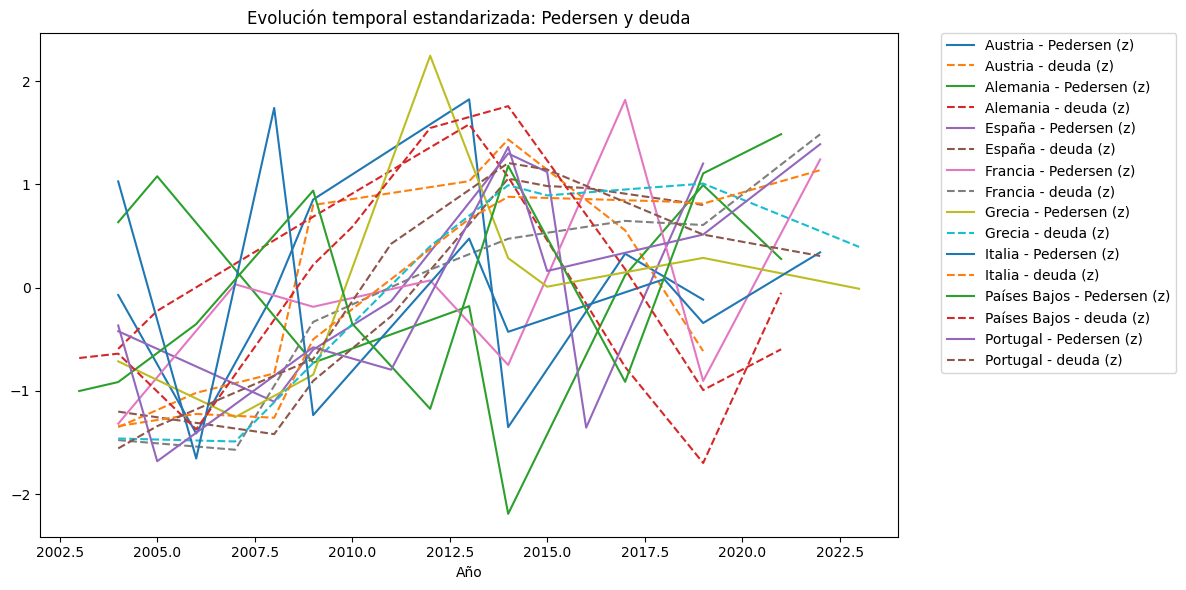

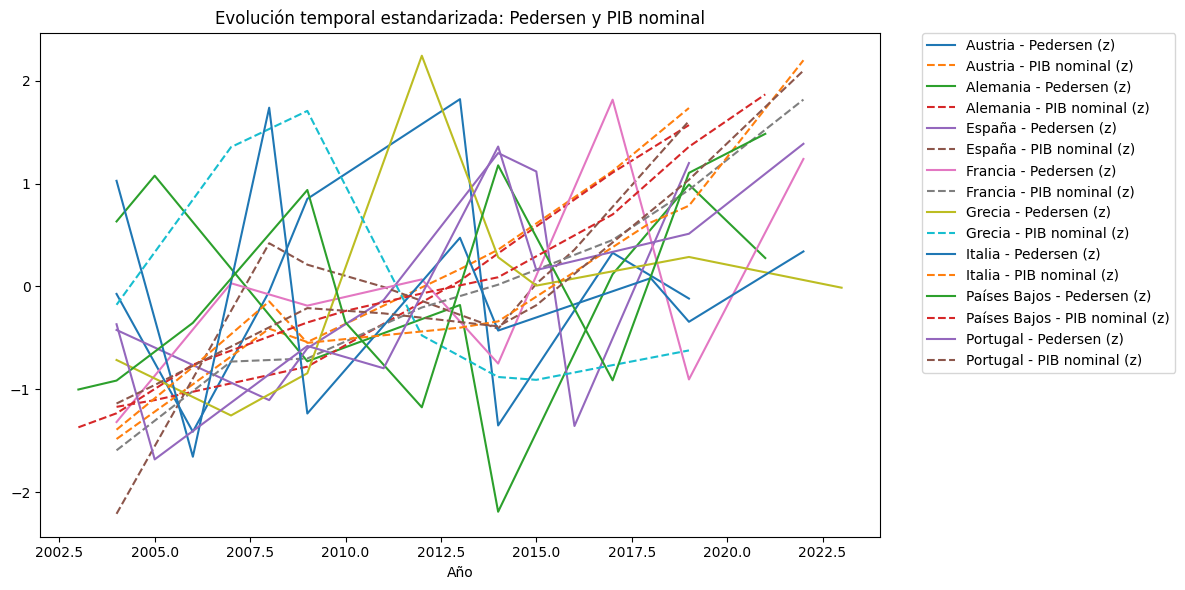

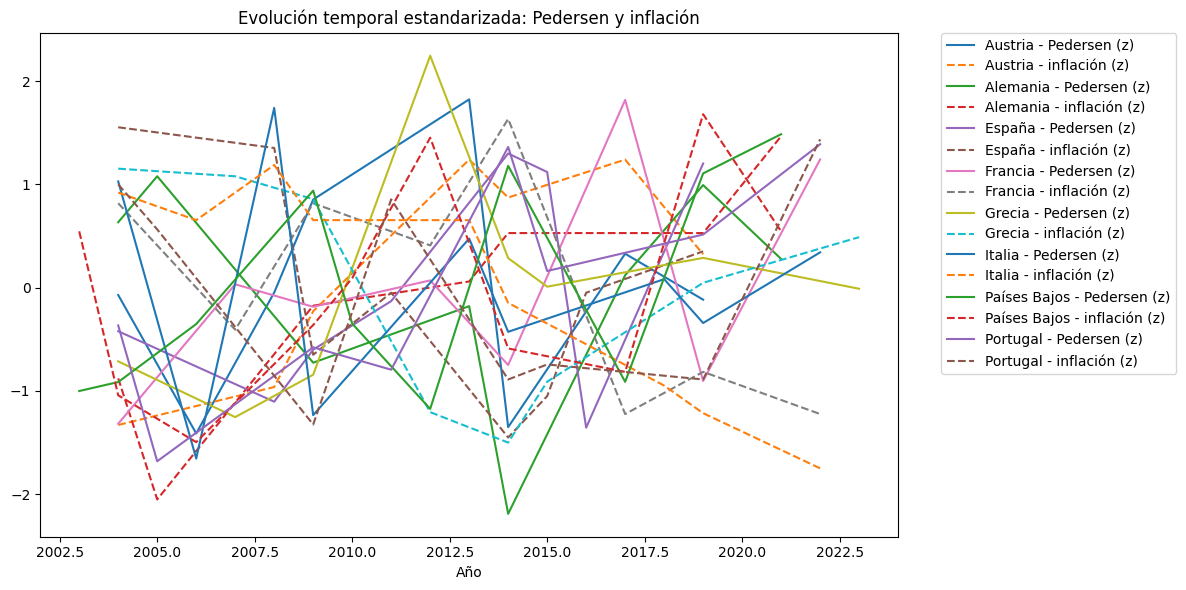

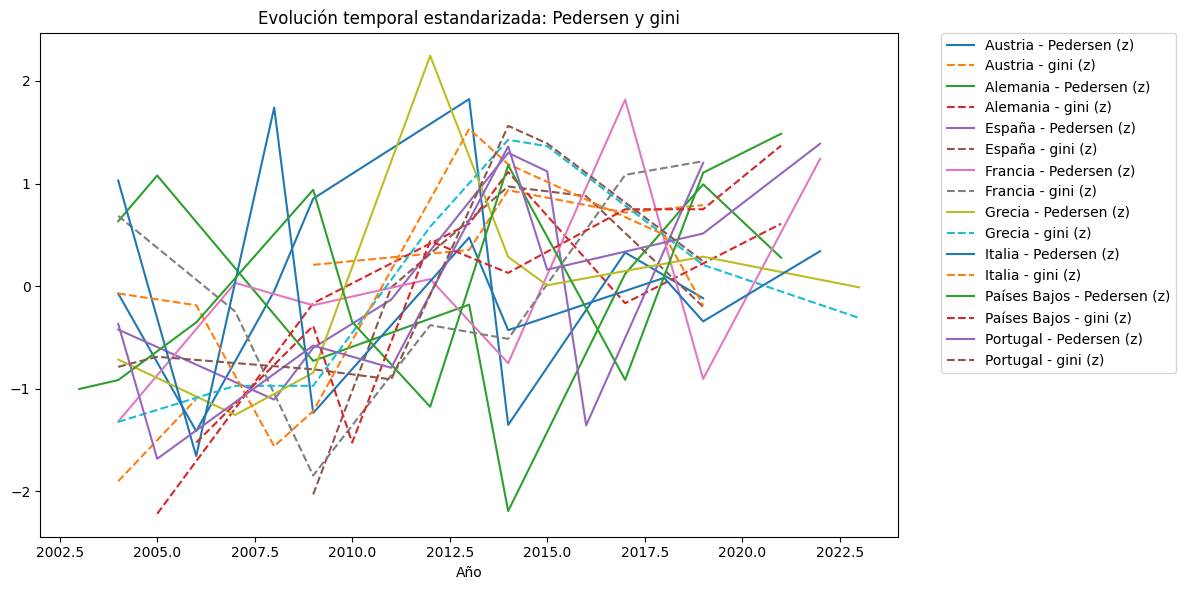

In [33]:
# Tendencias Temporales y Comparación Entre Países

# Estandarizar por país y variable
for var in ['debt_pct_gdp', 'gdp_nominal', 'inflation', 'gini', 'pedersen_index']:
    df_analysis[f'{var}_z'] = (
        df_analysis.groupby('country')[var]
        .transform(lambda x: StandardScaler().fit_transform(x.values.reshape(-1, 1)).flatten())
    )

# Diccionario para nombres bonitos
var_nombres = {
    'debt_pct_gdp_z': 'deuda',
    'gdp_nominal_z': 'PIB nominal',
    'inflation_z': 'inflación',
    'gini_z': 'gini'
}

# Gráficos de líneas de variables estandarizadas con años como enteros y nombres traducidos
for var in ['debt_pct_gdp_z', 'gdp_nominal_z', 'inflation_z', 'gini_z']:
    plt.figure(figsize=(12, 6))
    for country in df_analysis['country'].unique():
        subset = df_analysis[df_analysis['country'] == country]
        # Asegura que election_year es entero
        x_years = subset['election_year'].astype(int)
        plt.plot(x_years, subset['pedersen_index_z'], label=f"{country} - Pedersen (z)")
        plt.plot(x_years, subset[var], label=f"{country} - {var_nombres[var]} (z)", linestyle='--')
    plt.title(f'Evolución temporal estandarizada: Pedersen y {var_nombres[var]}')
    plt.xlabel('Año')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.show()

In [34]:
# Resumen de estadísticas descriptivas del índice de Pedersen por país

df_summary = df_analysis.groupby('country')['pedersen_index'].agg(
    mean='mean',
    std='std',
    min='min',
    max='max'
).reset_index()

print(df_summary)
# Guardar el resumen en un archivo CSV
df_summary.to_csv('df_tabla1.csv', index=False, encoding='latin1')


        country       mean        std     min     max
0      Alemania  16.401250   3.123296  10.000  19.550
1       Austria  18.091875   4.023045  12.775  24.950
2        España  18.350417   9.923048   5.755  30.400
3       Francia  34.785625   5.712115  27.740  44.495
4        Grecia  19.296563  12.526848   4.595  45.600
5        Italia  31.550556  15.616173   7.170  57.160
6  Países Bajos  23.395500   7.275287  15.285  33.645
7      Portugal  15.841250   5.028446   7.930  22.370


                   election_year  pedersen_index  employment_rate  \
election_year           1.000000        0.248420         0.185726   
pedersen_index          0.248420        1.000000        -0.141178   
employment_rate         0.185726       -0.141178         1.000000   
unemployment_rate      -0.137586        0.081707        -0.792030   
debt_pct_gdp            0.380890        0.225119        -0.790335   
gdp_nominal             0.190142        0.278374         0.152673   
gdp_real                0.112540        0.276484         0.126847   
inflation              -0.078413       -0.290041         0.634843   
gini                    0.329017       -0.078649        -0.358047   
debt_pct_gdp_z          0.580924        0.180573        -0.165263   
gdp_nominal_z           0.783918        0.091770         0.434869   
inflation_z            -0.046976       -0.155800         0.463306   
gini_z                  0.608227        0.164065        -0.040339   
pedersen_index_z        0.354112  

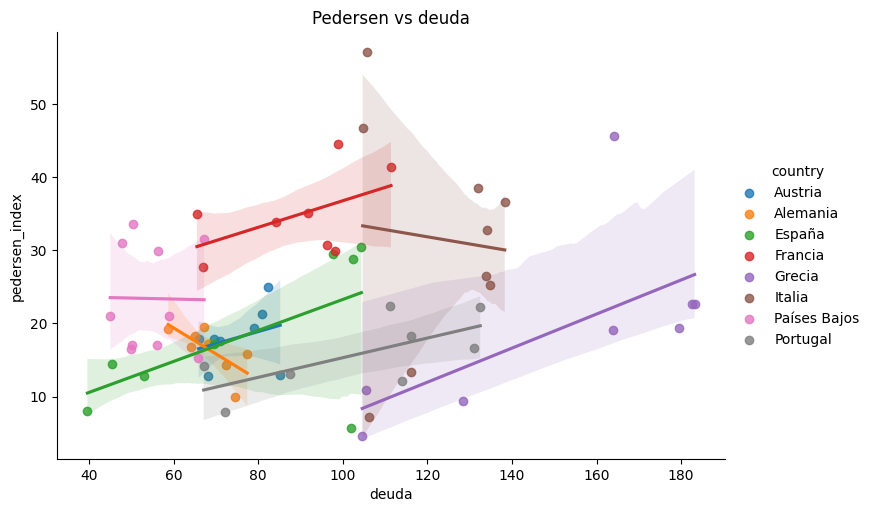

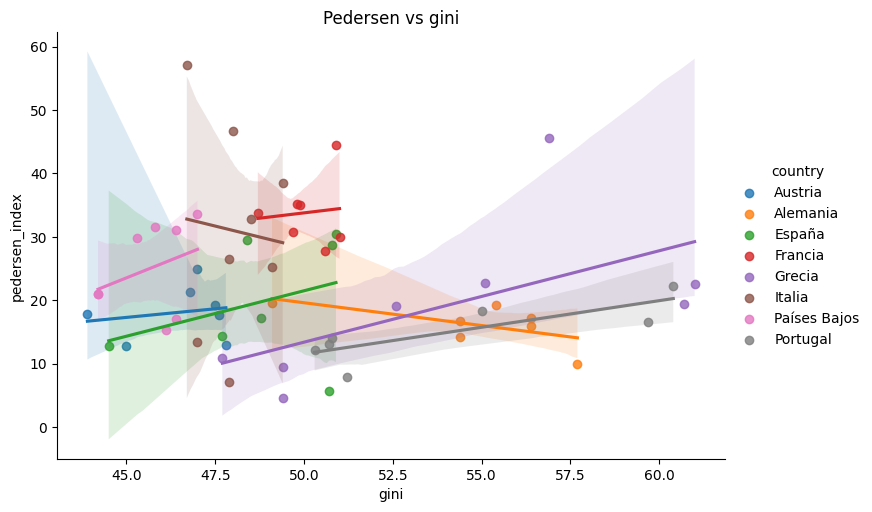

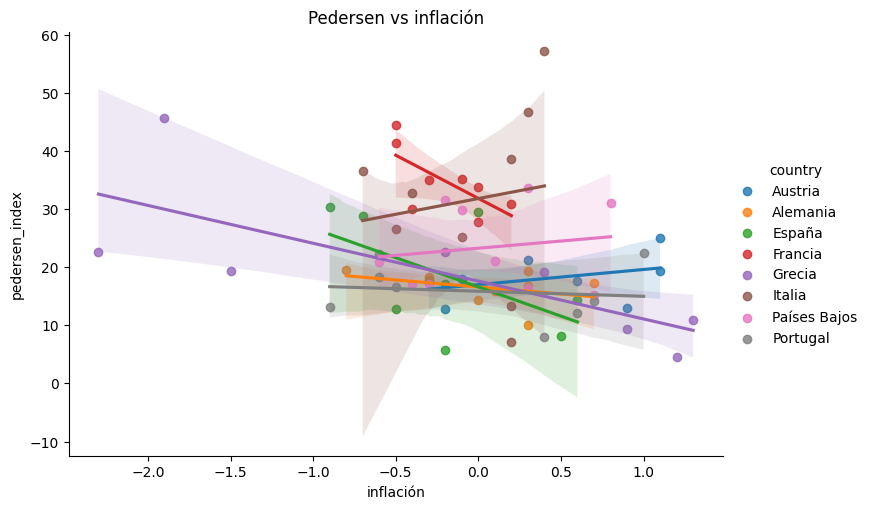

In [35]:
# Correlaciones y Relaciones Entre Variables

# Diccionario para nombres bonitos
var_nombres = {
    'debt_pct_gdp': 'deuda',
    'gini': 'gini',
    'inflation': 'inflación'
}

# Correlaciones cruzadas
print(df_analysis.corr(numeric_only=True))

# Gráficos de dispersión con regresión lineal para nuevas variables
for var in ['debt_pct_gdp', 'gini', 'inflation']:
    sns.lmplot(data=df_analysis, x=var, y='pedersen_index', hue='country', aspect=1.5)
    plt.title(f"Pedersen vs {var_nombres[var]}")
    plt.xlabel(var_nombres[var])
    plt.show()

                   election_year  pedersen_index  employment_rate  \
election_year           1.000000        0.248420         0.185726   
pedersen_index          0.248420        1.000000        -0.141178   
employment_rate         0.185726       -0.141178         1.000000   
unemployment_rate      -0.137586        0.081707        -0.792030   
debt_pct_gdp            0.380890        0.225119        -0.790335   
gdp_nominal             0.190142        0.278374         0.152673   
gdp_real                0.112540        0.276484         0.126847   
inflation              -0.078413       -0.290041         0.634843   
gini                    0.329017       -0.078649        -0.358047   
debt_pct_gdp_z          0.580924        0.180573        -0.165263   
gdp_nominal_z           0.783918        0.091770         0.434869   
inflation_z            -0.046976       -0.155800         0.463306   
gini_z                  0.608227        0.164065        -0.040339   
pedersen_index_z        0.354112  

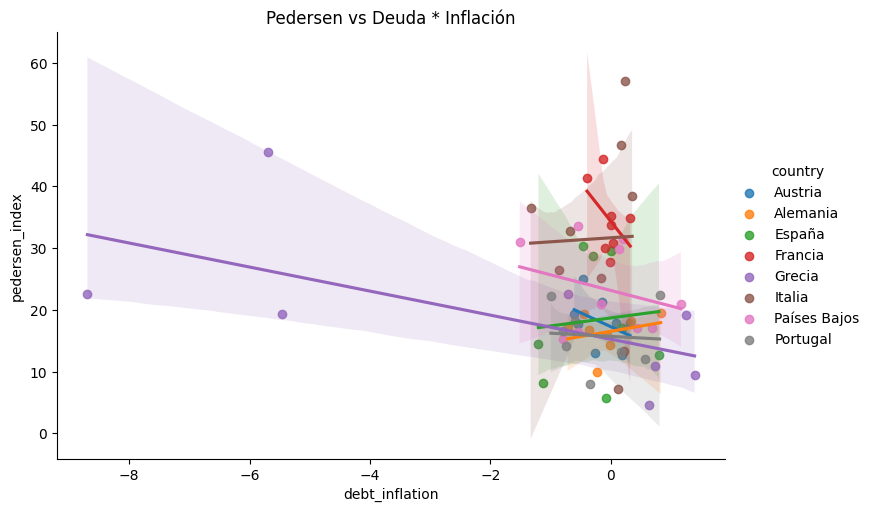

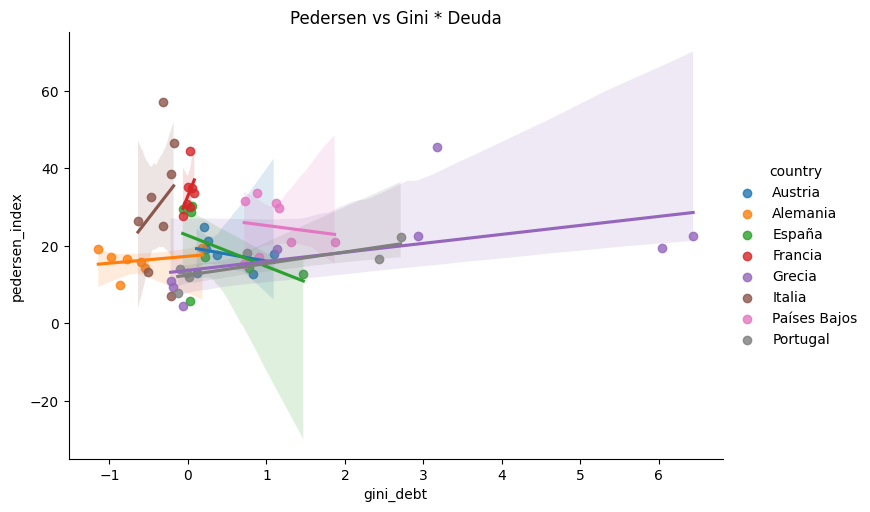

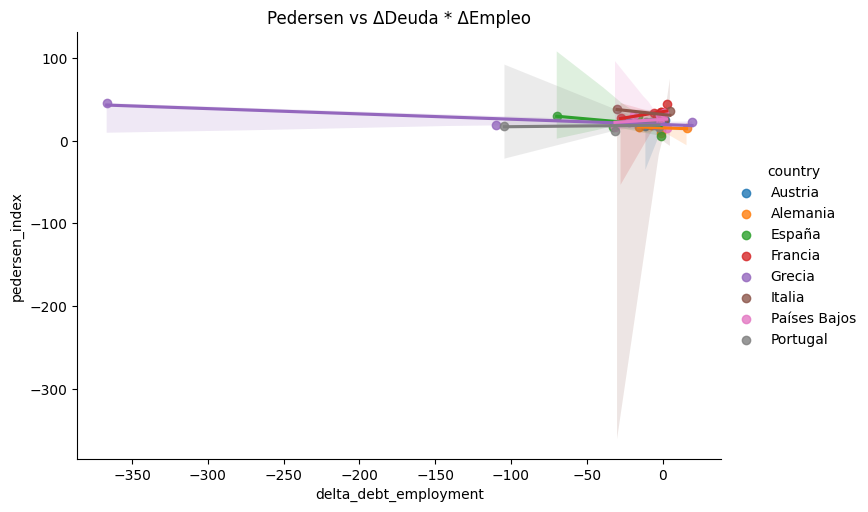

                       pedersen_index  debt_inflation  gini_debt  \
pedersen_index               1.000000       -0.151595   0.046837   
debt_inflation              -0.151595        1.000000  -0.745684   
gini_debt                    0.046837       -0.745684   1.000000   
delta_debt_employment       -0.296361        0.366269  -0.234394   

                       delta_debt_employment  
pedersen_index                     -0.296361  
debt_inflation                      0.366269  
gini_debt                          -0.234394  
delta_debt_employment               1.000000  


In [36]:
# Correlaciones y Relaciones Entre Variables

# Correlaciones cruzadas
print(df_analysis.corr(numeric_only=True))

# Estandarizar las variables económicas para facilitar la interpretación
scaler = StandardScaler()
for col in ['debt_pct_gdp', 'inflation', 'gini', 'employment_rate']:
    if col in df_analysis.columns:
        df_analysis[f'{col}_z'] = scaler.fit_transform(df_analysis[[col]])

# Crear interacciones relevantes
df_analysis['debt_inflation'] = df_analysis['debt_pct_gdp_z'] * df_analysis['inflation_z']
df_analysis['gini_debt'] = df_analysis['gini_z'] * df_analysis['debt_pct_gdp_z']
df_analysis['delta_debt_employment'] = df_analysis['debt_pct_gdp'].diff() * df_analysis['employment_rate'].diff()

# Gráficos de dispersión con regresión lineal para las interacciones
for var, label in zip(
    ['debt_inflation', 'gini_debt', 'delta_debt_employment'],
    ['Deuda * Inflación', 'Gini * Deuda', 'ΔDeuda * ΔEmpleo']
):
    sns.lmplot(data=df_analysis, x=var, y='pedersen_index', hue='country', aspect=1.5)
    plt.title(f'Pedersen vs {label}')
    plt.show()

# También puedes mostrar las correlaciones de las nuevas variables de interacción
print(df_analysis[['pedersen_index', 'debt_inflation', 'gini_debt', 'delta_debt_employment']].corr())

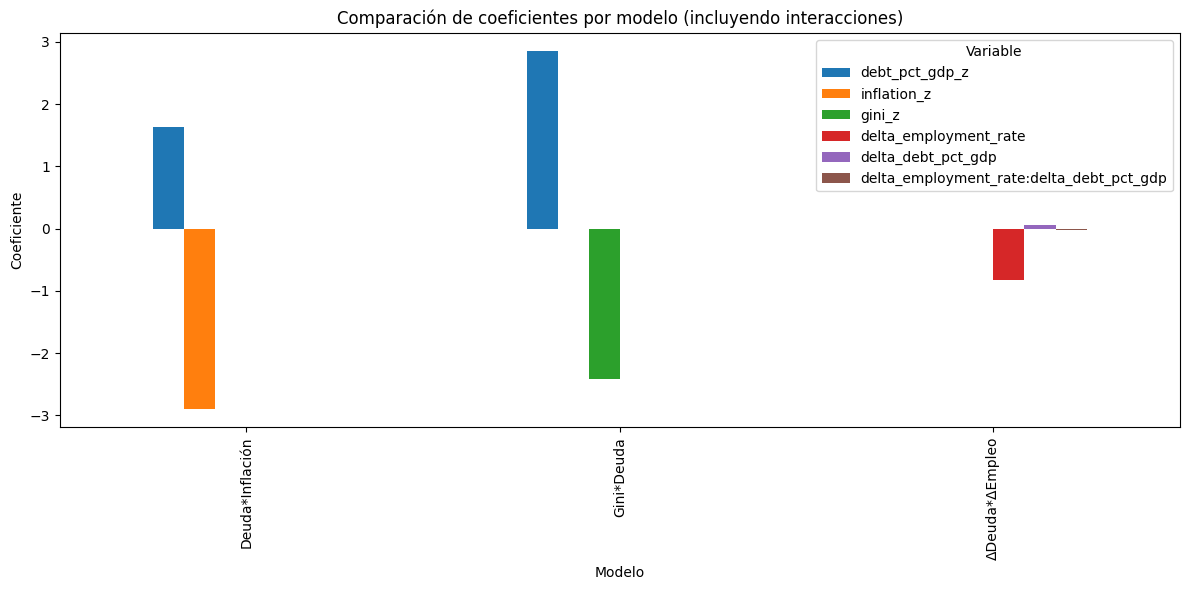

In [37]:
# Definir modelos de regresión lineal con interacciones

# Modelo 1: Deuda * Inflación
model_debt_infl = smf.ols('pedersen_index ~ debt_pct_gdp_z * inflation_z', data=df_analysis).fit()

# Modelo 2: Gini * Deuda
model_gini_debt = smf.ols('pedersen_index ~ gini_z * debt_pct_gdp_z', data=df_analysis).fit()

# Modelo 3: ΔDeuda * ΔEmpleo
df_analysis['delta_employment_rate'] = df_analysis.groupby('country')['employment_rate'].diff()
df_analysis['delta_debt_pct_gdp'] = df_analysis.groupby('country')['debt_pct_gdp'].diff()
model_delta = smf.ols('pedersen_index ~ delta_employment_rate * delta_debt_pct_gdp', data=df_analysis).fit()

# Comparar los resultados de los modelos
results = {
    'Deuda*Inflación': model_debt_infl,
    'Gini*Deuda': model_gini_debt,
    'ΔDeuda*ΔEmpleo': model_delta
}

coef_df = pd.DataFrame({c: m.params for c, m in results.items()}).T

cols_to_plot = [col for col in ['debt_pct_gdp_z', 'inflation_z', 'gini_z', 'debt_inflation', 'gini_debt', 'delta_debt_employment', 'delta_employment_rate', 'delta_debt_pct_gdp', 'delta_employment_rate:delta_debt_pct_gdp'] if col in coef_df.columns]
coef_df[cols_to_plot].plot(kind='bar', figsize=(12,6))
plt.title('Comparación de coeficientes por modelo (incluyendo interacciones)')
plt.ylabel('Coeficiente')
plt.xlabel('Modelo')
plt.legend(title='Variable')
plt.tight_layout()
plt.show()

In [54]:
summary_tables = []

for name, model in results.items():
    df = pd.DataFrame({
        'Coeficiente': model.params,
        'Error Std.': model.bse,
        'Valor p': model.pvalues.apply(lambda p: f"{p:.2e}")  # Notación científica
    })
    df['Variable'] = df.index
    df['Modelo'] = name
    summary_tables.append(df.reset_index(drop=True))

summary_df = pd.concat(summary_tables, ignore_index=True)
summary_df = summary_df[['Modelo', 'Variable', 'Coeficiente', 'Error Std.', 'Valor p']]
summary_df['Modelo'] = summary_df['Modelo'].str.replace('Δ', 'Delta')

# Guardar en CSV con latin1
summary_df.to_csv('resumen_modelos_interacciones_latin1.csv', index=False, encoding='latin1')

# Mostrar el resumen de los modelos
print(summary_df)

                    Modelo                                  Variable  \
0          Deuda*Inflación                                 Intercept   
1          Deuda*Inflación                            debt_pct_gdp_z   
2          Deuda*Inflación                               inflation_z   
3          Deuda*Inflación                debt_pct_gdp_z:inflation_z   
4               Gini*Deuda                                 Intercept   
5               Gini*Deuda                                    gini_z   
6               Gini*Deuda                            debt_pct_gdp_z   
7               Gini*Deuda                     gini_z:debt_pct_gdp_z   
8   DeltaDeuda*DeltaEmpleo                                 Intercept   
9   DeltaDeuda*DeltaEmpleo                     delta_employment_rate   
10  DeltaDeuda*DeltaEmpleo                        delta_debt_pct_gdp   
11  DeltaDeuda*DeltaEmpleo  delta_employment_rate:delta_debt_pct_gdp   

    Coeficiente  Error Std.   Valor p  
0     22.577067    1.35

In [39]:
# Preparación y Estandarización de Datos para PCA de GDP real y Gini

# Selecciona solo las columnas necesarias y elimina filas con NaN
pca_df = df_analysis[['gdp_real', 'gini']].dropna()

# Estandariza las variables
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_df)

# Aplica PCA para extraer un solo componente principal
pca = PCA(n_components=1)
pca_component = pca.fit_transform(pca_scaled)

# Añade el índice compuesto al DataFrame original (alineando índices)
df_analysis.loc[pca_df.index, 'indice_compuesto_gdp_gini'] = pca_component.flatten()

# Muestra los coeficientes (loadings) y la varianza explicada
print("Loadings del primer componente:", pca.components_)
print("Varianza explicada por el primer componente:", pca.explained_variance_ratio_[0])

# Ahora puedes usar 'indice_compuesto_gdp_gini' como variable sintética en tus análisis
print(df_analysis[['gdp_real', 'gini', 'indice_compuesto_gdp_gini']].head())

Loadings del primer componente: [[0.70710678 0.70710678]]
Varianza explicada por el primer componente: 0.5487447918948682
   gdp_real  gini  indice_compuesto_gdp_gini
0  238705.2  43.9                  -1.681536
1  253261.7  45.0                  -1.487159
2  267521.4   NaN                        NaN
3  256808.8  46.8                  -1.187497
4  271001.3  47.0                  -1.141670


In [40]:
# Definir subgrupos
subgrupo1 = ['Alemania', 'Austria', 'Países Bajos']
subgrupo2 = ['España', 'Francia', 'Italia', 'Grecia', 'Portugal']

# Evaluación estadística: mostrar resumen y métricas por subgrupo
from statsmodels.stats.outliers_influence import variance_inflation_factor

for nombre, paises in {'Democracias estables': subgrupo1, 'Democracias en crisis': subgrupo2}.items():
    print(f"\n--- {nombre} ---")
    df_sub = df_analysis[df_analysis['country'].isin(paises)].dropna()
    if df_sub.empty:
        print("No hay datos para este subgrupo.")
        continue
    X = df_sub[['debt_pct_gdp', 'inflation', 'indice_compuesto_gdp_gini']]
    X = sm.add_constant(X)
    y = df_sub['pedersen_index']
    model = sm.OLS(y, X, missing='drop').fit()
    print(f"R²: {model.rsquared:.2f}, AIC: {model.aic:.1f}, BIC: {model.bic:.1f}")
    print(model.summary().tables[1])  # Tabla de coeficientes y p-valores

    # Multicolinealidad: VIF por subgrupo
    vif = pd.DataFrame()
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif["variable"] = X.columns
    print(f"\nVIF para {nombre}:\n", vif)



--- Democracias estables ---
R²: 0.44, AIC: 93.9, BIC: 96.5
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        41.6272     10.406      4.000      0.003      18.442      64.813
debt_pct_gdp                 -0.3246      0.165     -1.966      0.078      -0.692       0.043
inflation                     1.2427      4.542      0.274      0.790      -8.877      11.363
indice_compuesto_gdp_gini    -1.6961      1.117     -1.518      0.160      -4.185       0.793

VIF para Democracias estables:
          VIF                   variable
0  40.022381                      const
1   1.299852               debt_pct_gdp
2   1.400892                  inflation
3   1.135251  indice_compuesto_gdp_gini

--- Democracias en crisis ---
R²: 0.15, AIC: 160.7, BIC: 164.8
                                coef    std err          t      P>|t|      [0.

c:\Users\santi\OneDrive\Documentos\VSC\tfg_venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)


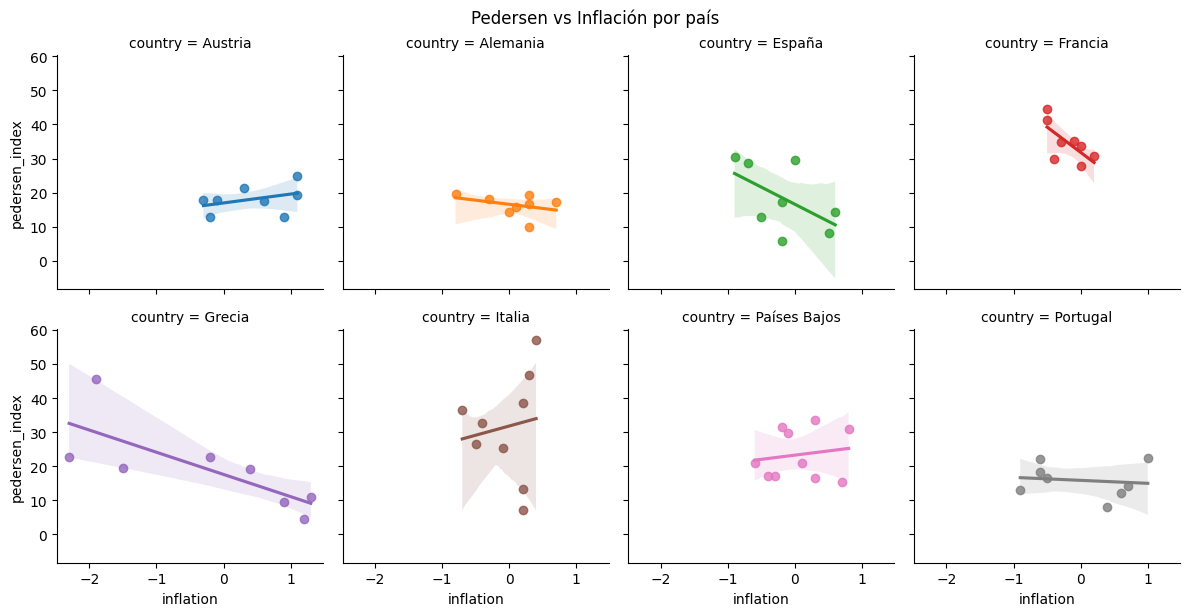

In [41]:
# Gráficos de dispersión con líneas de ajuste individuales por país para inflación
sns.lmplot(
    data=df_analysis,
    x='inflation',
    y='pedersen_index',
    hue='country',
    col='country',
    col_wrap=4,
    height=3,
    aspect=1
)
plt.suptitle('Pedersen vs Inflación por país', y=1.02)
plt.show()


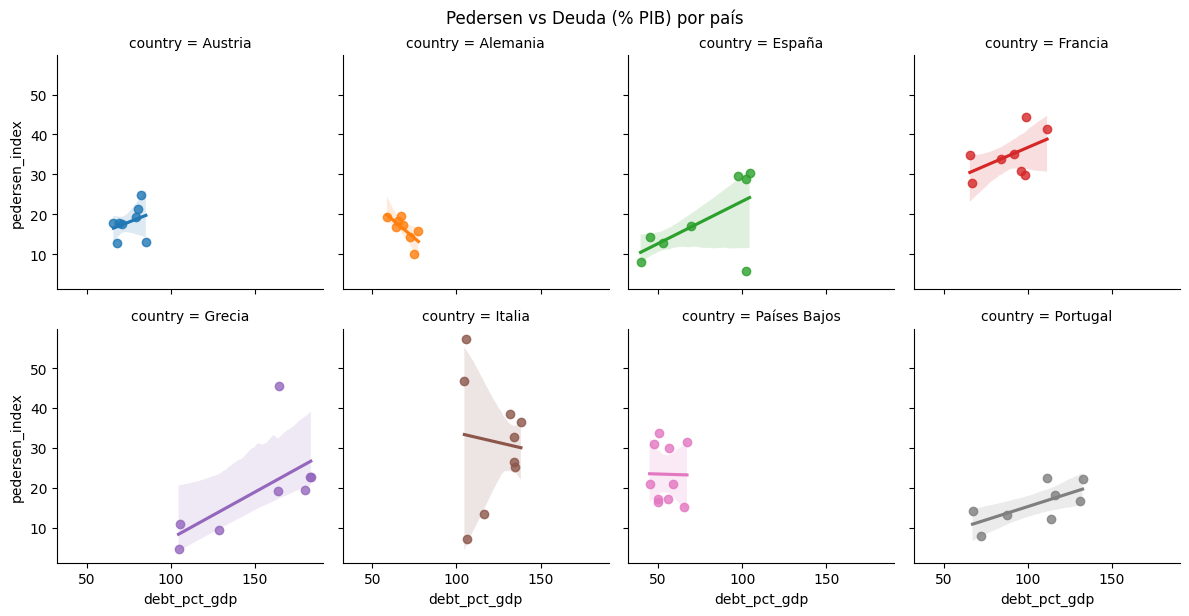

In [42]:
# Gráficos de dispersión con líneas de ajuste individuales por país para deuda
sns.lmplot(
    data=df_analysis,
    x='debt_pct_gdp',
    y='pedersen_index',
    hue='country',
    col='country',
    col_wrap=4,
    height=3,
    aspect=1
)
plt.suptitle('Pedersen vs Deuda (% PIB) por país', y=1.02)
plt.show()

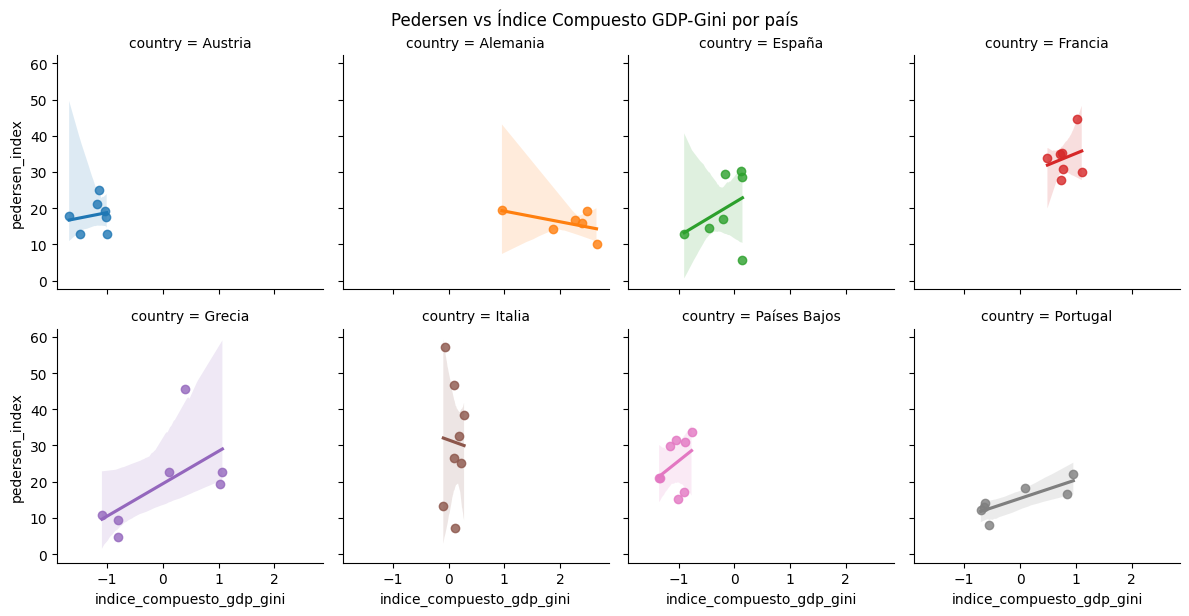

In [43]:
# Gráficos de dispersión con líneas de ajuste individuales por país para el índice compuesto GDP-Gini
sns.lmplot(
    data=df_analysis,
    x='indice_compuesto_gdp_gini',
    y='pedersen_index',
    hue='country',
    col='country',
    col_wrap=4,
    height=3,
    aspect=1
)
plt.suptitle('Pedersen vs Índice Compuesto GDP-Gini por país', y=1.02)
plt.show()

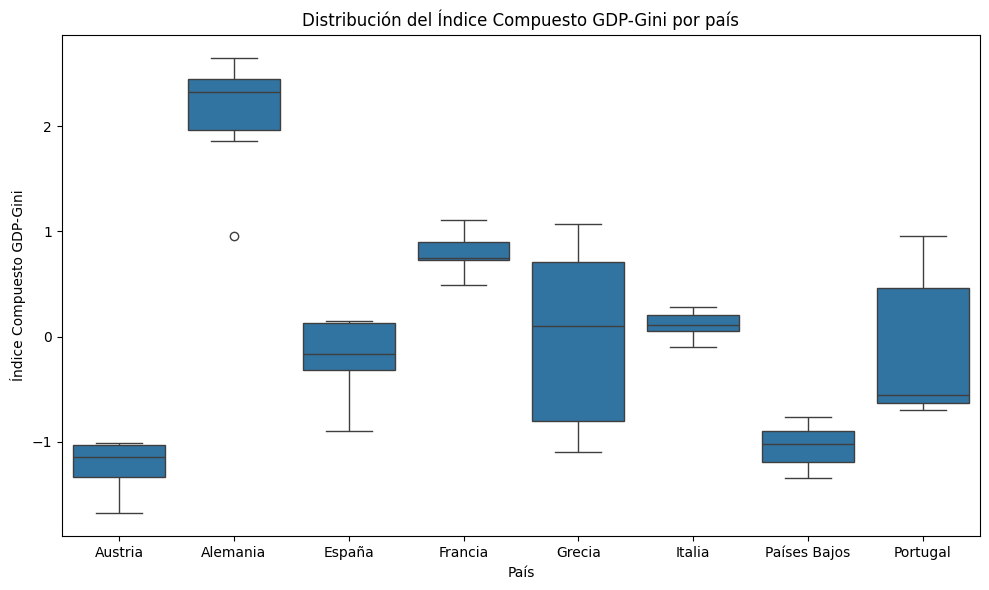

In [44]:
# Boxplot de Pedersen según el índice compuesto GDP-Gini por país
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_analysis,
    x='country',
    y='indice_compuesto_gdp_gini'
)
plt.title('Distribución del Índice Compuesto GDP-Gini por país')
plt.xlabel('País')
plt.ylabel('Índice Compuesto GDP-Gini')
plt.tight_layout()
plt.show()

In [45]:
# Delimitar el análisis de surgimiento de nuevos partidos solo a elecciones generales (parliament) de 2008 en adelante

# Diccionario para nombres completos en español
country_fullname = {
    'AT': 'Austria',
    'ES': 'España',
    'EL': 'Grecia',
    'IT': 'Italia',
    'FR': 'Francia',
    'DE': 'Alemania',
    'PT': 'Portugal',
    'NL': 'Países Bajos',
    'AUT': 'Austria',
    'ESP': 'España',
    'GRC': 'Grecia',
    'ITA': 'Italia',
    'FRA': 'Francia',
    'DEU': 'Alemania',
    'PRT': 'Portugal',
    'NLD': 'Países Bajos'
}

# Ajusta el filtro de años
years_post2008 = [y for y in years if y >= 2008]

df_election_filtrado = df_election[
    (df_election['country_name_short'].isin(selected_countries)) &
    (df_election['election_type'] == 'parliament') &  # Solo elecciones generales
    (df_election['election_year'].isin(years_post2008))
].copy()

df_election_filtrado = df_election_filtrado.sort_values(['country_name_short', 'election_year', 'party_id'])
df_election_filtrado['is_new_party'] = False

for country in df_election_filtrado['country_name_short'].unique():
    country_elections = df_election_filtrado[df_election_filtrado['country_name_short'] == country]
    for i, year in enumerate(sorted(country_elections['election_year'].unique())):
        if i == 0:
            continue  # No hay elección anterior
        prev_year = sorted(country_elections['election_year'].unique())[i-1]
        prev_parties = set(country_elections[country_elections['election_year'] == prev_year]['party_id'])
        curr_mask = (df_election_filtrado['country_name_short'] == country) & (df_election_filtrado['election_year'] == year)
        df_election_filtrado.loc[curr_mask, 'is_new_party'] = ~df_election_filtrado.loc[curr_mask, 'party_id'].isin(prev_parties)

# Calcula las estadísticas solo para el subconjunto filtrado
new_party_stats = (
    df_election_filtrado[df_election_filtrado['is_new_party']]
    .groupby(['country_name_short', 'election_year'])
    .agg(num_new_parties=('party_id', 'nunique'),
         vote_share_new_parties=('vote_share', 'sum'))
    .reset_index()
)

# Añade columna con nombre completo del país en español
new_party_stats['country_name'] = new_party_stats['country_name_short'].map(country_fullname)

# Reordena columnas para mostrar el nombre completo primero
cols = ['country_name', 'election_year', 'num_new_parties', 'vote_share_new_parties']
print(new_party_stats[cols])
# Guardar el DataFrame de nuevos partidos en un archivo CSV
new_party_stats[cols].to_csv('nuevos_partidos_post2008.csv', index=False, encoding='latin1')

    country_name  election_year  num_new_parties  vote_share_new_parties
0        Austria           2013                3                   11.70
1        Austria           2017                2                    5.40
2       Alemania           2013                1                    4.70
3       Alemania           2017                2                    2.00
4       Alemania           2021                3                    2.93
5         España           2011                3                    2.29
6         España           2015                8                   38.58
7         España           2019                6                   30.37
8        Francia           2017                7                   44.21
9        Francia           2022                4                    9.06
10        Grecia           2012                7                   53.67
11        Grecia           2015                5                   22.45
12        Grecia           2019                2   

In [46]:
# Analizar elecciones generales (parliament) y sus gabinetes posteriores

# Filtra solo elecciones generales de 2008 en adelante
years_post2008 = [y for y in years if y >= 2008]
df_election_filtrado = df_election[
    (df_election['country_name_short'].isin(selected_countries)) &
    (df_election['election_type'] == 'parliament') &
    (df_election['election_year'].isin(years_post2008))
].copy()

df_election_filtrado = df_election_filtrado.sort_values(['country_name_short', 'election_year', 'party_id'])
df_election_filtrado['is_new_party'] = False

for country in df_election_filtrado['country_name_short'].unique():
    country_elections = df_election_filtrado[df_election_filtrado['country_name_short'] == country]
    for i, year in enumerate(sorted(country_elections['election_year'].unique())):
        if i == 0:
            continue  # No hay elección anterior
        prev_year = sorted(country_elections['election_year'].unique())[i-1]
        prev_parties = set(country_elections[country_elections['election_year'] == prev_year]['party_id'])
        curr_mask = (df_election_filtrado['country_name_short'] == country) & (df_election_filtrado['election_year'] == year)
        df_election_filtrado.loc[curr_mask, 'is_new_party'] = ~df_election_filtrado.loc[curr_mask, 'party_id'].isin(prev_parties)

# Calcula las estadísticas solo para el subconjunto filtrado
new_party_stats = (
    df_election_filtrado[df_election_filtrado['is_new_party']]
    .groupby(['country_name_short', 'election_year'])
    .agg(num_new_parties=('party_id', 'nunique'),
         vote_share_new_parties=('vote_share', 'sum'))
    .reset_index()
)

# Filtra gabinetes solo para esos países y años
cabinet_stats = df_cabinet[
    (df_cabinet['country_name_short'].isin(new_party_stats['country_name_short'])) &
    (df_cabinet['year'].isin(new_party_stats['election_year']))
].copy()

cabinet_stats = cabinet_stats.sort_values(['country_name_short', 'year', 'start_date'])
cabinet_first = cabinet_stats.groupby(['country_name_short', 'year']).first().reset_index()

# Merge con new_party_stats
merged = pd.merge(
    new_party_stats,
    cabinet_first,
    left_on=['country_name_short', 'election_year'],
    right_on=['country_name_short', 'year'],
    how='left'
)

# Usa el nombre completo del país y el nombre completo del party
merged['country_name'] = merged['country_name_short'].map(country_fullname)
if 'party_name' in merged.columns:
    merged['party'] = merged['party_name']
elif 'party_name_short' in merged.columns:
    merged['party'] = merged['party_name_short']
else:
    merged['party'] = None

cols_to_show = [
    'country_name', 'election_year', 'num_new_parties', 'vote_share_new_parties', 'party', 'cabinet_name'
]
print(merged[cols_to_show])

    country_name  election_year  num_new_parties  vote_share_new_parties  \
0        Austria           2013                3                   11.70   
1        Austria           2017                2                    5.40   
2       Alemania           2013                1                    4.70   
3       Alemania           2017                2                    2.00   
4       Alemania           2021                3                    2.93   
5         España           2011                3                    2.29   
6         España           2015                8                   38.58   
7         España           2019                6                   30.37   
8        Francia           2017                7                   44.21   
9        Francia           2022                4                    9.06   
10        Grecia           2012                7                   53.67   
11        Grecia           2015                5                   22.45   
12        Gr

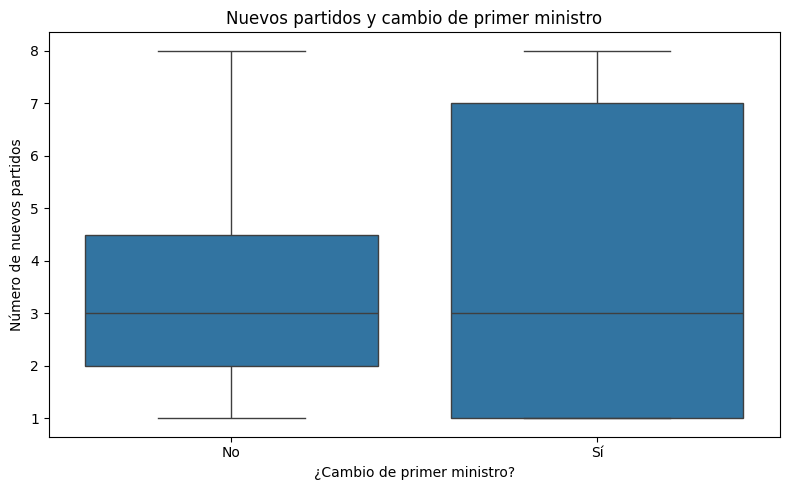

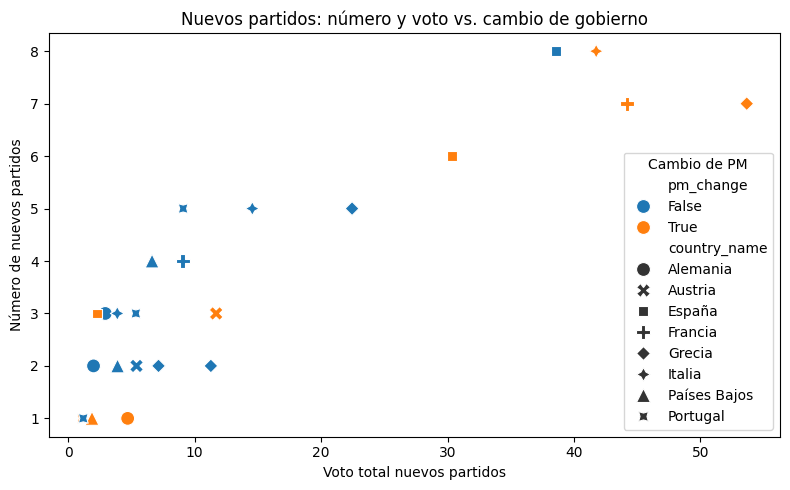

In [47]:
# 1. Create a flag for government change (change in prime minister)
merged = merged.sort_values(['country_name', 'election_year'])
merged['pm_change'] = merged.groupby('country_name')['prime_minister'].transform(lambda x: x != x.shift(1))

# 2. Visualization: Boxplot of new parties by government change
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=merged,
    x='pm_change',
    y='num_new_parties'
)
plt.title('Nuevos partidos y cambio de primer ministro')
plt.xlabel('¿Cambio de primer ministro?')
plt.ylabel('Número de nuevos partidos')
plt.xticks([0, 1], ['No', 'Sí'])
plt.tight_layout()
plt.show()

# 3. Scatter plot: Vote share of new parties vs. government change
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=merged,
    x='vote_share_new_parties',
    y='num_new_parties',
    hue='pm_change',
    style='country_name',
    s=100
)
plt.title('Nuevos partidos: número y voto vs. cambio de gobierno')
plt.xlabel('Voto total nuevos partidos')
plt.ylabel('Número de nuevos partidos')
plt.legend(title='Cambio de PM')
plt.tight_layout()
plt.show()